In [2]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import make_image_grid, load_image

pipeline = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipeline.enable_model_cpu_offload()
# remove following line if xFormers is not installed or you have PyTorch 2.0 or higher installed
pipeline.enable_xformers_memory_efficient_attention()

# prepare image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/img2img-init.png"
init_image = load_image(url)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

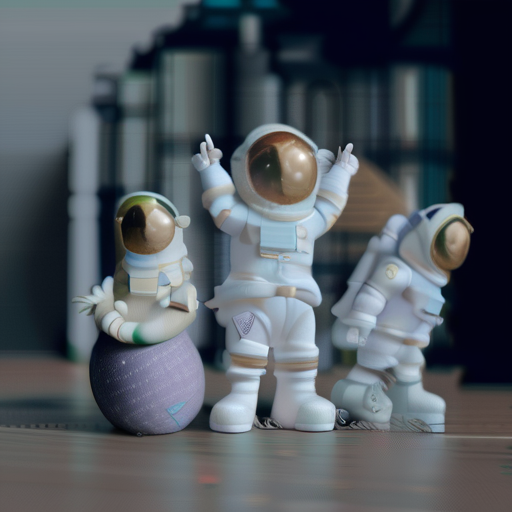

In [3]:
prompt = "Astronauts in a jungle"

# pass prompt and image to pipeline
pipeline(prompt, image=init_image, output_type="pil").images[0]

In [4]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="scheduler"
)

In [6]:
scheduler.prediction_type

/home/user-name-goes-here/.local/lib/python3.11/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `prediction_type` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'prediction_type' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.prediction_type'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


'epsilon'